In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.stats import kstest
from scipy.interpolate import interp1d

In [2]:
tracer = 'BGS_ANY'
fn = None

z_bins_dict = {'BGS_ANY': np.arange(-0.025, 0.7, 0.02), 'LRG': np.arange(-0.025, 1.5, 0.025), 'ELG': np.arange(0.6, 1.8, 0.025), 'QSO': np.arange(-0.025, 4.5, 0.1)}
vmax_dict = {'BGS_ANY': 1/3e4, 'LRG': 1/4e4, 'ELG': 1/6e4, 'QSO': 1/4e4}

# The following target bits are the same in both main and SV3
target_bits = {'LRG': 0, 'ELG': 1, 'QSO': 2, 'BGS_ANY': 60}
target_bit = target_bits[tracer]

if fn is None:
    fn_dict = {'BGS_ANY': 'ztile-main-bright-cumulative.fits', 'LRG': 'ztile-main-dark-cumulative.fits', 'ELG': 'ztile-main-dark-cumulative.fits', 'QSO': 'ztile-main-dark-cumulative.fits'}
    fn = os.path.join('/global/cfs/cdirs/desi/spectro/redux/himalayas/zcatalog', fn_dict[tracer])

min_nobs = 100

cat = Table(fitsio.read(fn, columns=['DESI_TARGET']))
idx = np.where(cat['DESI_TARGET'] & 2**target_bit > 0)[0]
cat = Table(fitsio.read(fn, rows=idx))
print(len(cat))

if 'Z_not4clus' in cat.colnames:
    cat.rename_column('Z_not4clus', 'Z')

cat['EFFTIME_BGS'] = 0.1400 * cat['TSNR2_BGS']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']

# Remove FIBERSTATUS!=0 fibers
mask = cat['COADD_FIBERSTATUS']==0
print('FIBERSTATUS   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Remove "no data" fibers
mask = cat['ZWARN'] & 2**9==0
print('No data   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

# Require a minimum depth for the cat coadd
if tracer=='BGS_ANY':
    min_depth = 160
    mask = cat['EFFTIME_BGS']>min_depth
else:
    min_depth = 800.
    mask = cat['EFFTIME_LRG']>min_depth
print('Min depth   ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
cat = cat[mask]

if tracer=='LRG':
    # Apply maskbits
    maskbits = [1, 8, 9, 11, 12, 13]
    mask = np.ones(len(cat), dtype=bool)
    for bit in maskbits:
        mask &= (cat['MASKBITS'] & 2**bit)==0
    print('MASKBITS  ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
    cat = cat[mask]
elif tracer=='ELG':
    # Apply maskbits
    maskbits = [1, 11, 12, 13]
    mask = np.ones(len(cat), dtype=bool)
    for bit in maskbits:
        mask &= (cat['MASKBITS'] & 2**bit)==0
    print('MASKBITS  ', np.sum(~mask), np.sum(mask), np.sum(~mask)/len(mask))
    cat = cat[mask]

# Remove duplicated objects
print(len(cat), len(np.unique(cat['TARGETID'])))
cat.sort('EFFTIME_LRG', reverse=True)
_, idx_keep = np.unique(cat['TARGETID'], return_index=True)
cat = cat[idx_keep]
print(len(cat), len(np.unique(cat['TARGETID'])))

6701704
FIBERSTATUS    147363 6554341 0.021988885214864758
No data    0 6554341 0.0
Min depth    225730 6328611 0.03443977052765488
6328611 6227859
6227859 6227859


In [3]:
fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
# too_few_fibers = fiberstats['FIBER'][fiberstats['n_tot']<=min_nobs]
# print(len(too_few_fibers))

1489.0


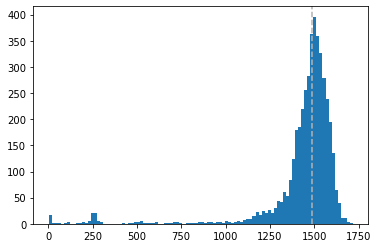

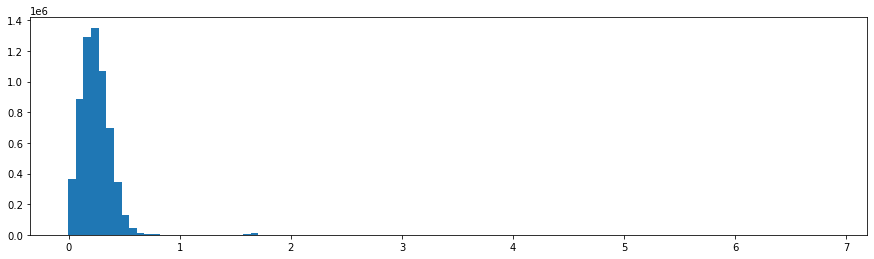

In [4]:
print(np.median(fiberstats['n_tot']))
plt.hist(fiberstats['n_tot'], 100)
plt.axvline(np.median(fiberstats['n_tot']), ls='--', color='0.7', lw=1.5)
plt.show()

plt.figure(figsize=(15, 4))
plt.hist(cat['Z'], 100)
plt.show()

In [5]:
pvalue_threshold = 1e-4

outliers = []

for iteration in range(2):
    
    print('iteration', iteration)

    mask = ~np.in1d(cat['FIBER'], outliers)
    allz = np.sort(np.array(cat['Z'][mask]))
    x = allz.copy()
    y = np.linspace(0, 1, len(x))
    cdf = interp1d(x, y, fill_value=(0, 1), bounds_error=False)

    fiberstats['pvalue'] = 0.
    for index, fiber in enumerate(fiberstats['FIBER']):
        # if index%1000==0:
        #     print(index, len(fiberstats))
        mask = cat['FIBER']==fiberstats['FIBER'][index]
        fiberstats['pvalue'][index] = kstest(cat['Z'][mask], cdf).pvalue

    fiberstats.sort('pvalue')

    mask_outlier = fiberstats['pvalue']<pvalue_threshold
    print(np.sum(mask_outlier))
    outliers = np.array(np.sort(fiberstats['FIBER'][mask_outlier]))
    print('Outlier fibers:', list(outliers))

    print()

iteration 0
9
Outlier fibers: [466, 1008, 1098, 1251, 2252, 3038, 3994, 4349, 4720]

iteration 1
9
Outlier fibers: [466, 1008, 1098, 1251, 2252, 3038, 3994, 4349, 4720]



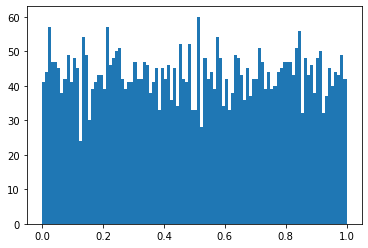

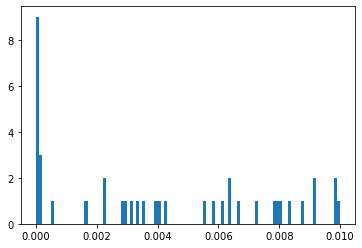

In [6]:
plt.hist(fiberstats['pvalue'], 100)
plt.show()

plt.hist(fiberstats['pvalue'], 100, range=(0, 0.01))
plt.show()

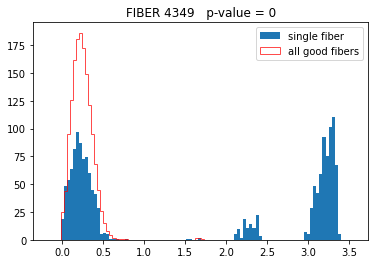

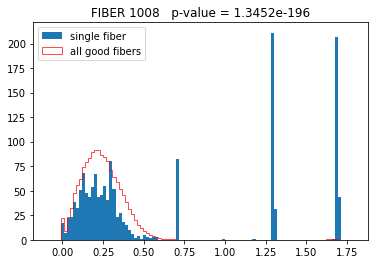

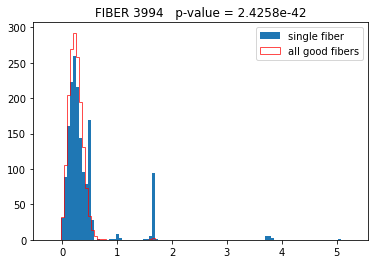

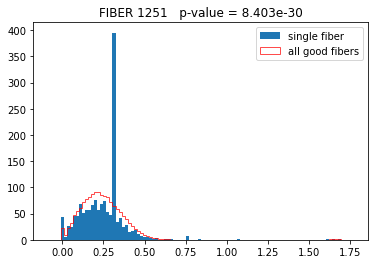

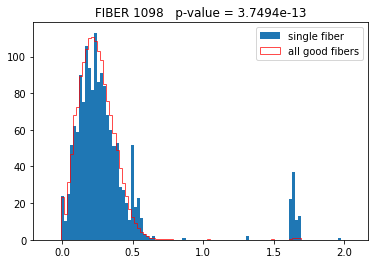

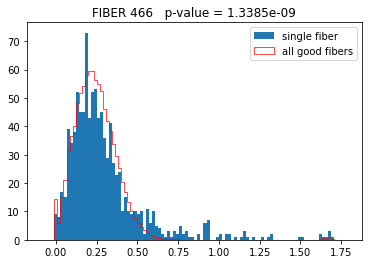

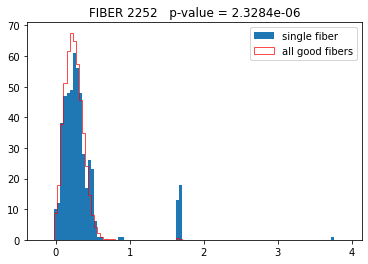

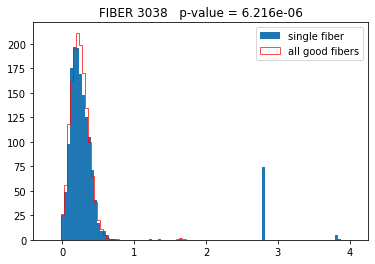

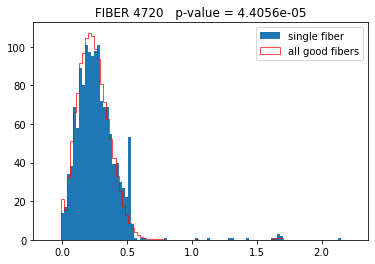

In [7]:
mask_outlier = fiberstats['pvalue']<pvalue_threshold

for index, fiber in enumerate(fiberstats['FIBER'][mask_outlier]):
    mask = cat['FIBER']==fiber
    vmin, vmax = cat['Z'][mask].min(), cat['Z'][mask].max()
    vmin = vmin - (vmax-vmin)*0.05
    vmax = vmax + (vmax-vmin)*0.05
    plt.hist(cat['Z'][mask], 100, range=(vmin, vmax), label='single fiber')
    mask1 = ~np.in1d(cat['FIBER'], fiberstats['FIBER'][mask_outlier])
    plt.hist(cat['Z'][mask1], 100, histtype='step', range=(vmin, vmax), weights=np.full(np.sum(mask1), np.sum(mask)/np.sum(mask1)), color='red', alpha=0.7, label='all good fibers')
    plt.title('FIBER {}   p-value = {:.5g}'.format(fiber, fiberstats['pvalue'][index]))
    plt.legend()
    plt.show()

------
## Bad fiber list based on spectrum VI results

In [5]:
outliers = [466, 2250, 2251, 2252, 2253, 3038]

mask = ~np.in1d(cat['FIBER'], outliers)
allz = np.sort(np.array(cat['Z'][mask]))
x = allz.copy()
y = np.linspace(0, 1, len(x))
cdf = interp1d(x, y, fill_value=(0, 1), bounds_error=False)

fiberstats = Table()
fiberstats['FIBER'], fiberstats['n_tot'] = np.unique(cat['FIBER'], return_counts=True)
fiberstats['pvalue'] = 0.
for index, fiber in enumerate(fiberstats['FIBER']):
    # if index%1000==0:
    #     print(index, len(fiberstats))
    mask = cat['FIBER']==fiberstats['FIBER'][index]
    fiberstats['pvalue'][index] = kstest(cat['Z'][mask], cdf).pvalue

FIBER 466


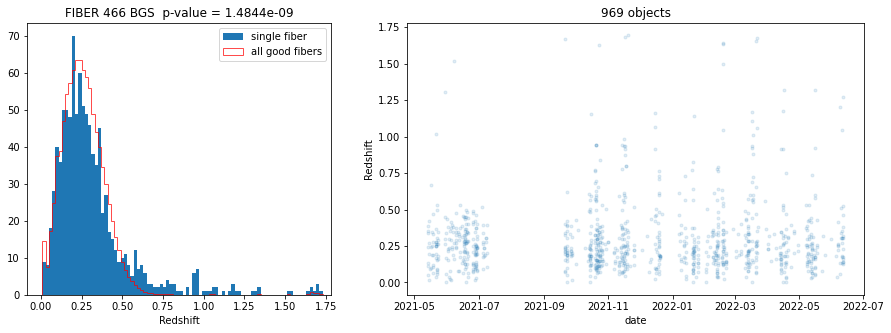

FIBER 2250


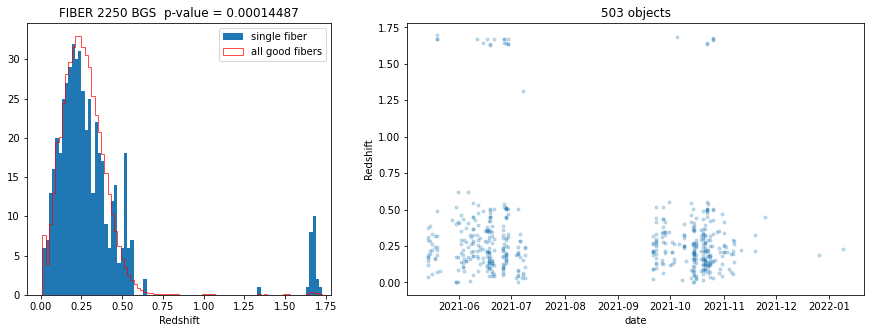

FIBER 2251


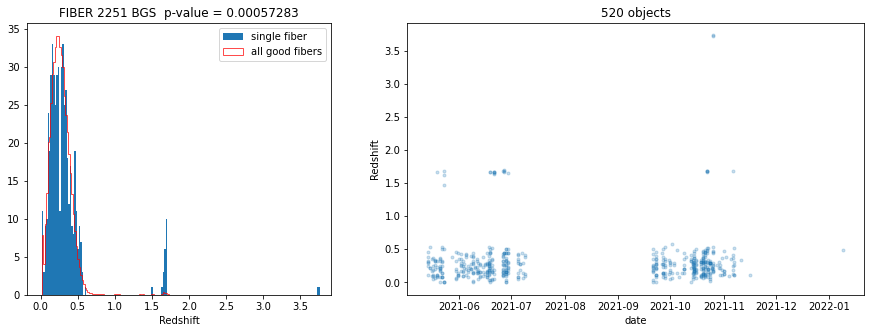

FIBER 2252


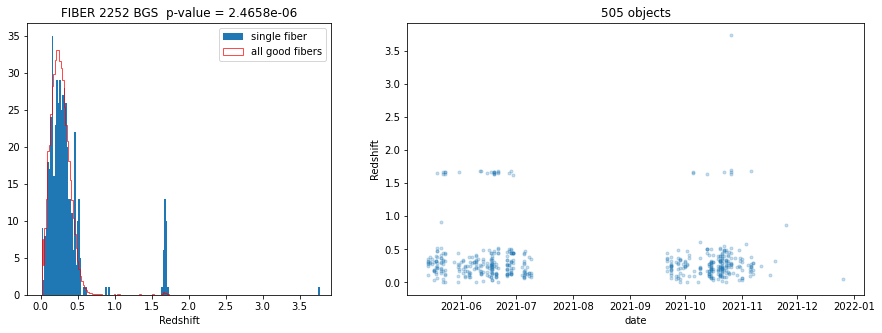

FIBER 2253


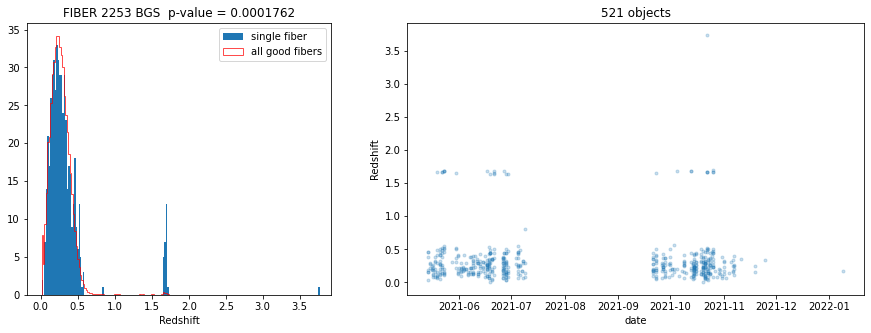

FIBER 3038


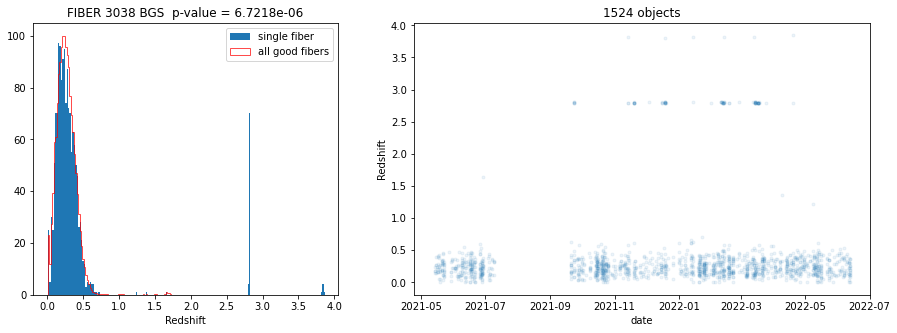

In [12]:
from datetime import datetime

mask_outlier = np.in1d(fiberstats['FIBER'], outliers)

bin_size = 0.02
bins = np.arange(-0.01, 10, bin_size)
bin_centers = (bins[1:]+bins[:-1])/2

for index, fiber in enumerate(fiberstats['FIBER'][mask_outlier]):

    print('FIBER {}'.format(fiber))
    mask = cat['FIBER']==fiber
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw={'width_ratios': [1, 1.5]})
    ax = axes[0]
    vmin, vmax = cat['Z'][mask].min(), cat['Z'][mask].max()
    vmin = vmin - (vmax-vmin)*0.05
    vmax = vmax + (vmax-vmin)*0.05
    ax.hist(bin_size*np.digitize(cat['Z'][mask], bins=bins), bins=bins, label='single fiber')
    mask1 = ~np.in1d(cat['FIBER'], fiberstats['FIBER'][mask_outlier])
    ax.hist(bin_size*np.digitize(cat['Z'][mask1], bins=bins), bins=bins, histtype='step', weights=np.full(np.sum(mask1), np.sum(mask)/np.sum(mask1)), color='red', alpha=0.7, label='all good fibers')
    ax.set_title('FIBER {} BGS  p-value = {:.5g}'.format(fiber, fiberstats['pvalue'][mask_outlier][index]))
    ax.set_xlabel('Redshift')
    ax.set_xlim(vmin, vmax)
    ax.legend()
    
    ax = axes[1]
    cat1 = cat[mask]
    dates = np.asarray([datetime.strptime(str(night), '%Y%m%d') for night in cat1['LASTNIGHT']])
    ax.plot(dates, cat1['Z'], '.', alpha=np.minimum(0.5, 0.2*600/len(cat1)))
    ax.set_title('{} objects'.format(len(cat1)))
    ax.set_xlabel('date')
    ax.set_ylabel('Redshift')
    plt.show()